In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
customers = pd.read_csv('/content/drive/MyDrive/HV assignment /customers.csv')
loans = pd.read_csv('/content/drive/MyDrive/HV assignment /loans.csv')
applications = pd.read_csv('/content/drive/MyDrive/HV assignment /applications.csv')
transactions = pd.read_csv('/content/drive/MyDrive/HV assignment /transactions.csv')
defaults = pd.read_csv('/content/drive/MyDrive/HV assignment /defaults.csv')
branches = pd.read_csv('/content/drive/MyDrive/HV assignment /branches.csv')

/tmp/ipython-input-84453124.py:3: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv('/content/drive/MyDrive/HV assignment /applications.csv')


In [4]:
datasets = {
    'customers': customers,
    'loans': loans,
    'applications': applications,
    'transactions': transactions,
    'defaults': defaults,
    'branches': branches
}

In [5]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.info())


CUSTOMERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Customer_ID              70000 non-null  object
 1   Full_Name                70000 non-null  object
 2   Contact_Number           70000 non-null  int64 
 3   Email                    70000 non-null  object
 4   Address                  70000 non-null  object
 5   Age                      70000 non-null  int64 
 6   Gender                   70000 non-null  object
 7   Marital_Status           70000 non-null  object
 8   Employment_Status        70000 non-null  object
 9   Annual_Income            70000 non-null  int64 
 10  Credit_Score             70000 non-null  int64 
 11  Region                   70000 non-null  object
 12  Account_Tenure           70000 non-null  object
 13  Relationship_Manager_ID  70000 non-null  object
dtypes: int64(4), object(10)
mem

#Task 1
Data Quality and Preparation

In [6]:
for name, df in datasets.items():
    df.drop_duplicates(inplace=True)


In [7]:
missing_values = {
    name: df.isnull().sum()
    for name, df in datasets.items()
}
missing_values

{'customers': Customer_ID                0
 Full_Name                  0
 Contact_Number             0
 Email                      0
 Address                    0
 Age                        0
 Gender                     0
 Marital_Status             0
 Employment_Status          0
 Annual_Income              0
 Credit_Score               0
 Region                     0
 Account_Tenure             0
 Relationship_Manager_ID    0
 dtype: int64,
 'loans': Loan_ID                     0
 Customer_ID                 0
 Loan_Amount                 0
 Interest_Rate               0
 Loan_Term                   0
 Disbursal_Date              0
 Repayment_Start_Date        0
 Repayment_End_Date          0
 Loan_Status                 0
 Overdue_Amount              0
 EMI_Amount                  0
 Collateral_Details      30194
 dtype: int64,
 'applications': Application_ID          0
 Loan_ID             12600
 Customer_ID             0
 Application_Date        0
 Approval_Date       12600
 Loan

In [8]:
duplicate_counts = {
    name: df.duplicated().sum()
    for name, df in datasets.items()
}
duplicate_counts

{'customers': np.int64(0),
 'loans': np.int64(0),
 'applications': np.int64(0),
 'transactions': np.int64(0),
 'defaults': np.int64(0),
 'branches': np.int64(0)}

In [9]:
inconsistent_data = {
    'loans_invalid_amount': (loans['Loan_Amount'] <= 0).sum(),
    'loans_invalid_interest': (loans['Interest_Rate'] <= 0).sum(),
    'loans_invalid_emi': (loans['EMI_Amount'] <= 0).sum(),
    'loans_invalid_overdue': (loans['Overdue_Amount'] < 0).sum(),
    'defaults_invalid_default_amount': (defaults['Default_Amount'] < 0).sum(),
    'defaults_invalid_recovery_amount': (defaults['Recovery_Amount'] < 0).sum()
}
inconsistent_data

{'loans_invalid_amount': np.int64(0),
 'loans_invalid_interest': np.int64(0),
 'loans_invalid_emi': np.int64(0),
 'loans_invalid_overdue': np.int64(0),
 'defaults_invalid_default_amount': np.int64(0),
 'defaults_invalid_recovery_amount': np.int64(0)}

In [10]:
# Standardize date formats
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'], errors='coerce')
loans['Repayment_Start_Date'] = pd.to_datetime(loans['Repayment_Start_Date'], errors='coerce')
loans['Repayment_End_Date'] = pd.to_datetime(loans['Repayment_End_Date'], errors='coerce')

In [11]:
applications['Application_Date'] = pd.to_datetime(applications['Application_Date'], errors='coerce')
applications['Approval_Date'] = pd.to_datetime(applications['Approval_Date'], errors='coerce')

In [12]:
transactions['Transaction_Date'] = pd.to_datetime(transactions['Transaction_Date'], errors='coerce')

In [13]:
defaults['Default_Date'] = pd.to_datetime(defaults['Default_Date'], errors='coerce')

In [14]:
# Handle outliers in numeric columns
loans = loans[
    (loans['Loan_Amount'] > 0) &
    (loans['Interest_Rate'] > 0)
]

In [15]:
defaults = defaults[
    defaults['Default_Amount'] >= 0
]

#Task 2
Descriptive Analysis


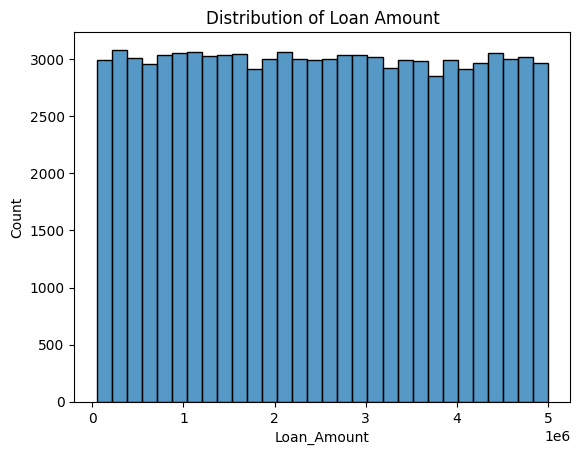

In [16]:
# Distribution of Loan Amount
plt.figure()
sns.histplot(loans['Loan_Amount'], bins=30)
plt.title('Distribution of Loan Amount')
plt.show()

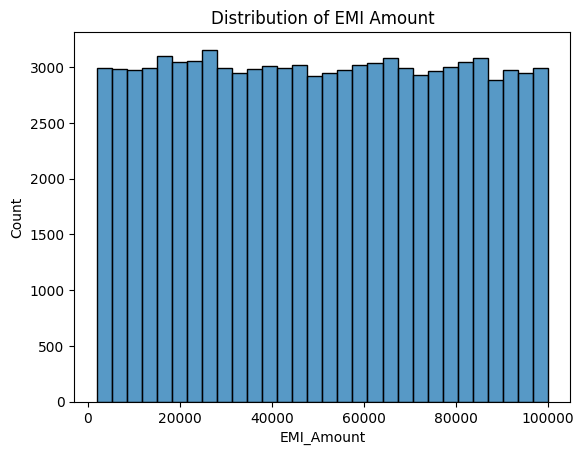

In [17]:
# Distribution of EMI Amount
plt.figure()
sns.histplot(loans['EMI_Amount'], bins=30)
plt.title('Distribution of EMI Amount')
plt.show()

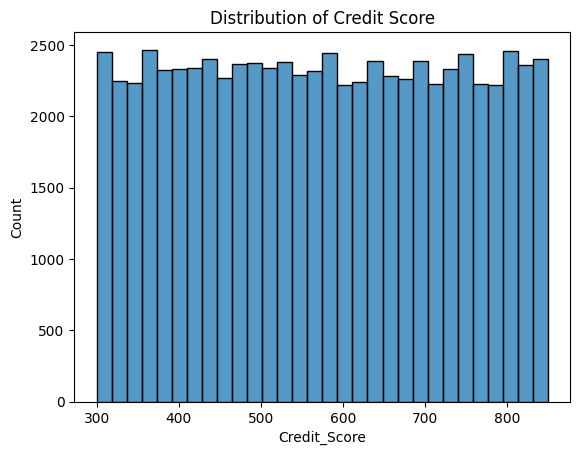

In [18]:
# Distribution of Credit Score
plt.figure()
sns.histplot(customers['Credit_Score'], bins=30)
plt.title('Distribution of Credit Score')
plt.show()

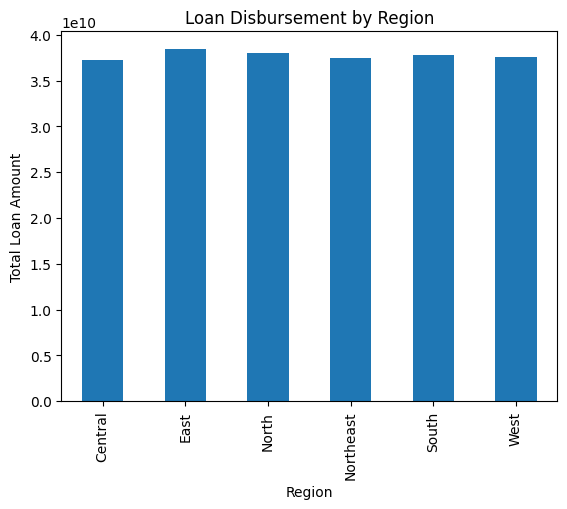

In [19]:
# Loan disbursement by region
loan_region = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
).groupby('Region')['Loan_Amount'].sum()
plt.figure()
loan_region.plot(kind='bar')
plt.title('Loan Disbursement by Region')
plt.xlabel('Region')
plt.ylabel('Total Loan Amount')
plt.show()

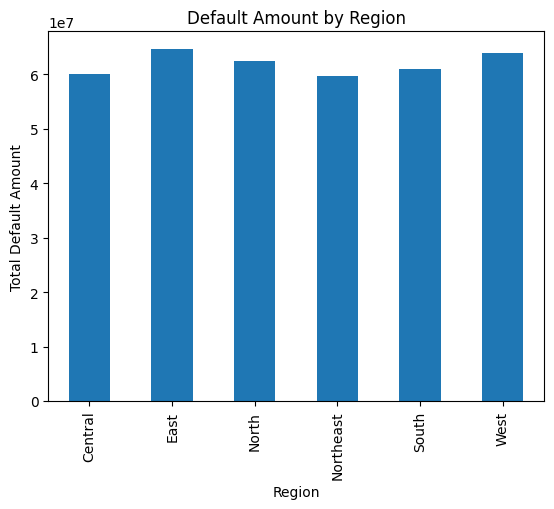

In [20]:
# Default amount by region
default_region = defaults.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
).groupby('Region')['Default_Amount'].sum()
plt.figure()
default_region.plot(kind='bar')
plt.title('Default Amount by Region')
plt.xlabel('Region')
plt.ylabel('Total Default Amount')
plt.show()

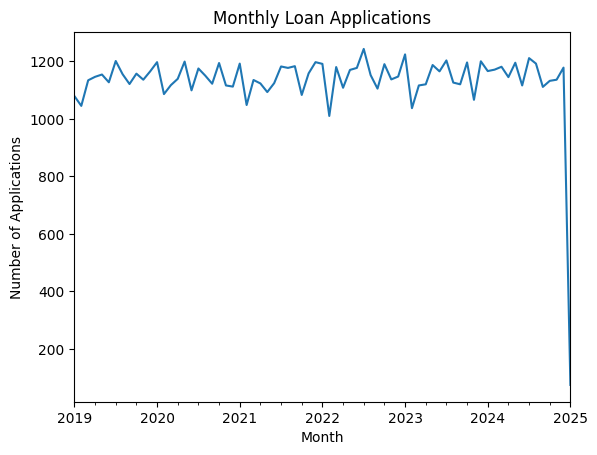

In [21]:
# Monthly loan approvals
applications['Application_Month'] = applications['Application_Date'].dt.to_period('M')
monthly_approvals = applications.groupby('Application_Month').size()
plt.figure()
monthly_approvals.plot()
plt.title('Monthly Loan Applications')
plt.xlabel('Month')
plt.ylabel('Number of Applications')
plt.show()

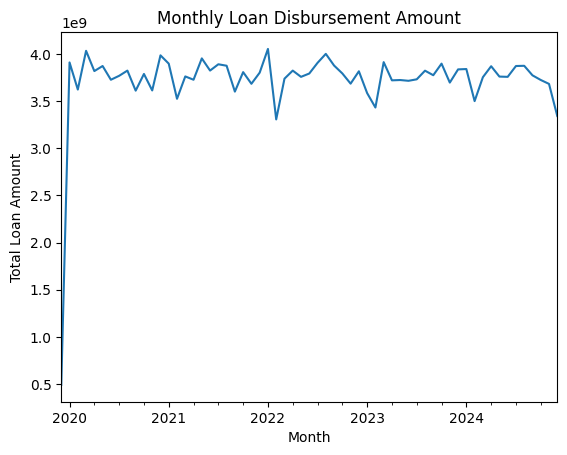

In [22]:
# Monthly loan disbursements
loans['Disbursal_Month'] = loans['Disbursal_Date'].dt.to_period('M')
monthly_disbursement = loans.groupby('Disbursal_Month')['Loan_Amount'].sum()
plt.figure()
monthly_disbursement.plot()
plt.title('Monthly Loan Disbursement Amount')
plt.xlabel('Month')
plt.ylabel('Total Loan Amount')
plt.show()

#Task 3
Default Risk Analysis

In [23]:
# Create Default_Flag
default_flag = defaults[['Loan_ID']].drop_duplicates()
default_flag['Default_Flag'] = 1
# Merge Default_Flag with loans
loan_default = loans.merge(
    default_flag,
    on='Loan_ID',
    how='left'
)
loan_default['Default_Flag'] = loan_default['Default_Flag'].fillna(0)
# Merge Credit_Score
loan_default = loan_default.merge(
    customers[['Customer_ID', 'Credit_Score']],
    on='Customer_ID',
    how='left'
)
# Correlation calculation
correlation_matrix = loan_default[
    ['Loan_Amount', 'Interest_Rate', 'Credit_Score', 'Default_Flag']
].corr()
correlation_matrix

,Loan_Amount,Interest_Rate,Credit_Score,Default_Flag
Loan_Amount,1.000000,-0.003201,0.000139,-0.003313
Interest_Rate,-0.003201,1.000000,0.002457,-0.003750
Credit_Score,0.000139,0.002457,1.000000,-0.001580
Default_Flag,-0.003313,-0.003750,-0.001580,1.000000


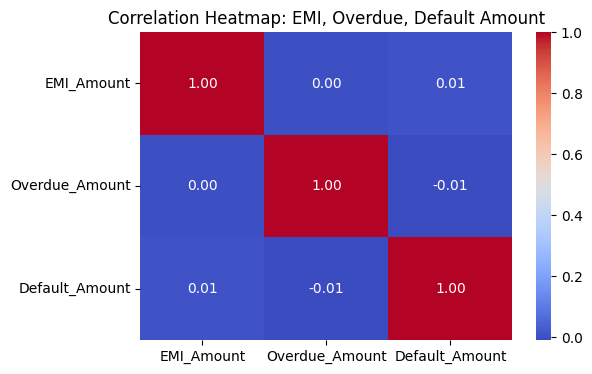

In [24]:
emi_default = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)
corr_data = emi_default[['EMI_Amount', 'Overdue_Amount', 'Default_Amount']]
corr_matrix = corr_data.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: EMI, Overdue, Default Amount')
plt.show()

In [25]:
loan_branch = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
branch_defaults = loan_branch.merge(
    defaults[['Loan_ID']],
    on='Loan_ID',
    how='left',
    indicator=True
)
branch_defaults['Is_Default'] = (branch_defaults['_merge'] == 'both').astype(int)
branch_default_rate = branch_defaults.groupby('Region')['Is_Default'].mean().reset_index()
branch_default_rate.rename(columns={'Is_Default': 'Default_Rate'}, inplace=True)
branch_corr = branches.merge(
    branch_default_rate,
    on='Region',
    how='left'
)
branch_correlation = branch_corr[
    ['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Default_Rate']
].corr()
branch_correlation

,Delinquent_Loans,Loan_Disbursement_Amount,Default_Rate
Delinquent_Loans,1.000000,0.023648,-0.066070
Loan_Disbursement_Amount,0.023648,1.000000,0.071269
Default_Rate,-0.066070,0.071269,1.000000


#Task 4
Branch and Regional Performance

In [26]:
branch_processing_rank = branches[
    ['Branch_ID', 'Branch_Name', 'Region', 'Avg_Processing_Time']
].sort_values(by='Avg_Processing_Time', ascending=True)
branch_processing_rank

,Branch_ID,Branch_Name,Region,Avg_Processing_Time
49,B050,Sani-Kale,North,1
17,B018,"Sandhu, Magar and Sachdeva",Northeast,2
46,B047,Chawla-Tandon,East,2
41,B042,Kar-Jaggi,West,2
44,B045,Solanki-Shah,South,3
11,B012,Kaul Inc,West,3
26,B027,Kapadia-Ramakrishnan,West,3
47,B048,Chawla-Subramanian,Central,4
32,B033,"Saini, Iyer and Sani",South,5
22,B023,"Wable, Butala and Kakar",South,5


In [27]:
loan_branch = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
loan_branch = loan_branch.merge(
    defaults[['Loan_ID', 'Default_Amount', 'Recovery_Amount']],
    on='Loan_ID',
    how='left'
)
loan_branch['Is_Default'] = loan_branch['Default_Amount'].notna().astype(int)
branch_metrics = loan_branch.groupby('Region').agg(
    Total_Loans=('Loan_ID', 'count'),
    Defaulted_Loans=('Is_Default', 'sum'),
    Total_Default_Amount=('Default_Amount', 'sum'),
    Total_Recovery_Amount=('Recovery_Amount', 'sum')
).reset_index()
branch_metrics['Default_Rate'] = branch_metrics['Defaulted_Loans'] / branch_metrics['Total_Loans']
branch_metrics['Recovery_Rate'] = (
    branch_metrics['Total_Recovery_Amount'] / branch_metrics['Total_Default_Amount']
)
branch_default_rank = branch_metrics.sort_values(by='Default_Rate', ascending=False)
branch_recovery_rank = branch_metrics.sort_values(by='Recovery_Rate', ascending=False)
branch_default_rank, branch_recovery_rank

(      Region  Total_Loans  Defaulted_Loans  Total_Default_Amount  \
 4      South        15030             1582            84636861.0   
 5       West        14990             1569            83055601.0   
 0    Central        14925             1499            79038057.0   
 3  Northeast        15015             1503            77502469.0   
 2      North        15117             1416            76685540.0   
 1       East        15384             1431            75889229.0   
 
    Total_Recovery_Amount  Default_Rate  Recovery_Rate  
 4             19698015.0      0.105256       0.232736  
 5             19430517.0      0.104670       0.233946  
 0             19798520.0      0.100436       0.250494  
 3             20463973.0      0.100100       0.264043  
 2             19040479.0      0.093669       0.248293  
 1             17488309.0      0.093019       0.230445  ,
       Region  Total_Loans  Defaulted_Loans  Total_Default_Amount  \
 3  Northeast        15015             1503   

#Task 5
Customer Segmentation

In [28]:
customers['Income_Segment'] = pd.cut(
    customers['Annual_Income'],
    bins=[0, 300000, 700000, float('inf')],
    labels=['Low Income', 'Middle Income', 'High Income']
)
customers['Credit_Segment'] = pd.cut(
    customers['Credit_Score'],
    bins=[0, 600, 750, 900],
    labels=['Low Credit', 'Medium Credit', 'High Credit']
)
customer_loan_status = loans[['Customer_ID', 'Loan_Status']].drop_duplicates()
customer_segments = customers.merge(
    customer_loan_status,
    on='Customer_ID',
    how='left'
)
customer_segments[['Customer_ID', 'Income_Segment', 'Credit_Segment', 'Loan_Status']]

,Customer_ID,Income_Segment,Credit_Segment,Loan_Status
0,C000001,High Income,Low Credit,NaN
1,C000002,Middle Income,Low Credit,NaN
2,C000003,High Income,Medium Credit,Closed
3,C000003,High Income,Medium Credit,Overdue
4,C000004,Middle Income,Low Credit,Closed
...,...,...,...,...
92643,C069997,High Income,High Credit,Active
92644,C069998,Middle Income,Medium Credit,Overdue
92645,C069999,High Income,High Credit,Active
92646,C070000,High Income,High Credit,Closed


In [29]:
defaulted_customers = defaults[['Customer_ID']].drop_duplicates()
defaulted_customers['Is_Default'] = 1
customer_risk_value = customer_segments.merge(
    defaulted_customers,
    on='Customer_ID',
    how='left'
)
customer_risk_value['Is_Default'] = customer_risk_value['Is_Default'].fillna(0)
high_value_customers = customer_risk_value[
    (customer_risk_value['Income_Segment'] == 'High Income') &
    (customer_risk_value['Credit_Segment'] == 'High Credit') &
    (customer_risk_value['Is_Default'] == 0)
]
high_risk_customers = customer_risk_value[
    (customer_risk_value['Credit_Segment'] == 'Low Credit') &
    (customer_risk_value['Is_Default'] == 1)
]
high_value_customers[['Customer_ID', 'Income_Segment', 'Credit_Segment']], \
high_risk_customers[['Customer_ID', 'Income_Segment', 'Credit_Segment']]

(      Customer_ID Income_Segment Credit_Segment
 12        C000010    High Income    High Credit
 22        C000017    High Income    High Credit
 52        C000040    High Income    High Credit
 61        C000046    High Income    High Credit
 70        C000053    High Income    High Credit
 ...           ...            ...            ...
 92631     C069987    High Income    High Credit
 92643     C069997    High Income    High Credit
 92645     C069999    High Income    High Credit
 92646     C070000    High Income    High Credit
 92647     C070000    High Income    High Credit
 
 [11030 rows x 3 columns],
       Customer_ID Income_Segment Credit_Segment
 11        C000009  Middle Income     Low Credit
 24        C000019  Middle Income     Low Credit
 25        C000019  Middle Income     Low Credit
 51        C000039  Middle Income     Low Credit
 65        C000050  Middle Income     Low Credit
 ...           ...            ...            ...
 92551     C069927  Middle Income     Lo

In [30]:
repayment_data = transactions.merge(
    customer_segments[['Customer_ID', 'Income_Segment', 'Credit_Segment']],
    on='Customer_ID',
    how='left'
)
repayment_behavior = repayment_data.groupby(
    ['Income_Segment', 'Credit_Segment']
).agg(
    Total_Payment=('Amount', 'sum'),
    Avg_Overdue_Fee=('Overdue_Fee', 'mean'),
    Transaction_Count=('Transaction_ID', 'count')
).reset_index()
repayment_behavior

/tmp/ipython-input-2206876756.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  repayment_behavior = repayment_data.groupby(


,Income_Segment,Credit_Segment,Total_Payment,Avg_Overdue_Fee,Transaction_Count
0,Low Income,Low Credit,694226718,1277.288840,27195
1,Low Income,Medium Credit,323270337,1292.101253,12691
2,Low Income,High Credit,205950309,1223.032725,8159
3,Middle Income,Low Credit,2627797045,1286.681472,103071
4,Middle Income,Medium Credit,1249847261,1265.244589,49017
5,Middle Income,High Credit,853009607,1269.294794,33386
6,High Income,Low Credit,8464936408,1272.001116,332399
7,High Income,Medium Credit,4199157827,1267.158292,164816
8,High Income,High Credit,2825233814,1275.343692,110241


#Task 6
Advanced Statistical Analysis

In [31]:
default_flag = defaults[['Loan_ID']].drop_duplicates()
default_flag['Default_Flag'] = 1
loan_risk = loans.merge(
    default_flag,
    on='Loan_ID',
    how='left'
)
loan_risk['Default_Flag'] = loan_risk['Default_Flag'].fillna(0)
loan_risk = loan_risk.merge(
    customers[['Customer_ID', 'Credit_Score']],
    on='Customer_ID',
    how='left'
)
risk_correlation = loan_risk[
    ['Credit_Score', 'Loan_Amount', 'Interest_Rate', 'Overdue_Amount', 'Default_Flag']
].corr()
risk_correlation

,Credit_Score,Loan_Amount,Interest_Rate,Overdue_Amount,Default_Flag
Credit_Score,1.000000,0.000139,0.002457,0.001570,-0.001580
Loan_Amount,0.000139,1.000000,-0.003201,0.008400,-0.003313
Interest_Rate,0.002457,-0.003201,1.000000,-0.002199,-0.003750
Overdue_Amount,0.001570,0.008400,-0.002199,1.000000,-0.000687
Default_Flag,-0.001580,-0.003313,-0.003750,-0.000687,1.000000


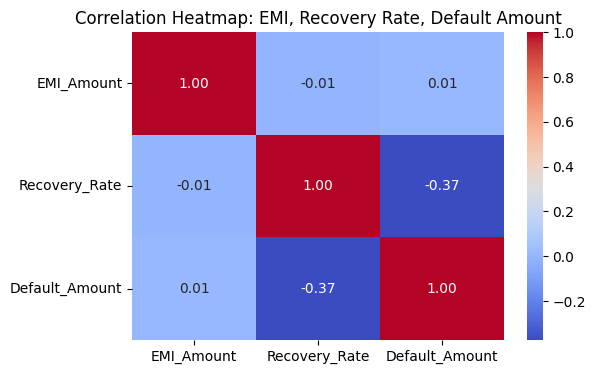

In [32]:
loan_recovery = loans.merge(
    defaults[['Loan_ID', 'Default_Amount', 'Recovery_Amount']],
    on='Loan_ID',
    how='left'
)
loan_recovery['Recovery_Rate'] = (
    loan_recovery['Recovery_Amount'] / loan_recovery['Default_Amount']
)
corr_data = loan_recovery[['EMI_Amount', 'Recovery_Rate', 'Default_Amount']]
corr_matrix = corr_data.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: EMI, Recovery Rate, Default Amount')
plt.show()

In [33]:
loan_recovery = loans.merge(
    defaults[['Loan_ID', 'Default_Amount', 'Recovery_Amount']],
    on='Loan_ID',
    how='left'
)
loan_recovery['Recovery_Rate'] = (
    loan_recovery['Recovery_Amount'] / loan_recovery['Default_Amount']
)
loan_recovery = loan_recovery.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
branch_recovery = loan_recovery.groupby('Region').agg(
    Avg_Recovery_Rate=('Recovery_Rate', 'mean')
).reset_index()
branch_analysis = branches.merge(
    branch_recovery,
    on='Region',
    how='left'
)
branch_level_correlation = branch_analysis[
    ['Delinquent_Loans', 'Loan_Disbursement_Amount', 'Avg_Recovery_Rate']
].corr()
branch_level_correlation

,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Recovery_Rate
Delinquent_Loans,1.000000,0.023648,0.127043
Loan_Disbursement_Amount,0.023648,1.000000,-0.072335
Avg_Recovery_Rate,0.127043,-0.072335,1.000000


#Task 7
Transaction and Recovery Analysis

In [34]:
transactions['Transaction_Month'] = transactions['Transaction_Date'].dt.to_period('M')
penalty_trends = transactions.groupby('Transaction_Month').agg(
    Total_Overdue_Fee=('Overdue_Fee', 'sum'),
    Avg_Overdue_Fee=('Overdue_Fee', 'mean'),
    Transaction_Count=('Transaction_ID', 'count')
).reset_index()
penalty_trends

,Transaction_Month,Total_Overdue_Fee,Avg_Overdue_Fee,Transaction_Count
0,2019-12,1285371,1224.162857,1050
1,2020-01,10632607,1256.066982,8465
2,2020-02,10326010,1283.212377,8047
3,2020-03,10563729,1252.814160,8432
4,2020-04,10138560,1259.604920,8049
...,...,...,...,...
56,2024-08,10497858,1248.555899,8408
57,2024-09,10540312,1282.588464,8218
58,2024-10,10721377,1280.776132,8371
59,2024-11,10434479,1281.719568,8141


In [35]:
defaults['Recovery_Rate'] = defaults['Recovery_Amount'] / defaults['Default_Amount']
recovery_analysis = defaults.groupby(
    ['Default_Reason', 'Legal_Action']
).agg(
    Avg_Recovery_Rate=('Recovery_Rate', 'mean'),
    Total_Default_Amount=('Default_Amount', 'sum'),
    Total_Recovery_Amount=('Recovery_Amount', 'sum')
).reset_index()
recovery_analysis

,Default_Reason,Legal_Action,Avg_Recovery_Rate,Total_Default_Amount,Total_Recovery_Amount
0,Business Failure,No,0.404936,60275246,14962918
1,Business Failure,Yes,0.402335,61650737,14855675
2,Job Loss,No,0.393805,57241270,13068979
3,Job Loss,Yes,0.418474,56236139,13766243
4,Medical Emergency,No,0.420908,62314181,15495404
5,Medical Emergency,Yes,0.414707,56769115,14767756
6,Other,No,0.386740,62257272,14931148
7,Other,Yes,0.394871,60063797,14071690


In [36]:
defaults_region = defaults.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
region_recovery = defaults_region.groupby('Region').agg(
    Total_Default_Amount=('Default_Amount', 'sum'),
    Total_Recovery_Amount=('Recovery_Amount', 'sum')
).reset_index()
region_recovery['Recovery_Rate'] = (
    region_recovery['Total_Recovery_Amount'] /
    region_recovery['Total_Default_Amount']
)
branch_recovery = branches.merge(
    region_recovery[['Region', 'Recovery_Rate']],
    on='Region',
    how='left'
)
region_recovery, branch_recovery

(      Region  Total_Default_Amount  Total_Recovery_Amount  Recovery_Rate
 0    Central              60166820               14279370       0.237330
 1       East              64656315               14484667       0.224026
 2      North              62378265               15563080       0.249495
 3  Northeast              59756404               14270424       0.238810
 4      South              60965366               15766509       0.258614
 5       West              64012891               14926765       0.233184,
    Branch_ID                   Branch_Name     Region  Total_Customers  \
 0       B001          Dhar, Kant and Madan       West             2891   
 1       B002                    Shan Group       East             4459   
 2       B003              Sachdev-Banerjee    Central             2504   
 3       B004                  Kapadia-Brar       East             1542   
 4       B005        Mangal, Kaur and Borde      South              945   
 5       B006                  

#Task 8
EMI Analysis


In [37]:
default_flag = defaults[['Loan_ID']].drop_duplicates()
default_flag['Default_Flag'] = 1
emi_default = loans.merge(
    default_flag,
    on='Loan_ID',
    how='left'
)
emi_default['Default_Flag'] = emi_default['Default_Flag'].fillna(0)
emi_default['EMI_Bucket'] = pd.qcut(
    emi_default['EMI_Amount'],
    q=5,
    duplicates='drop'
)
emi_default_probability = emi_default.groupby('EMI_Bucket').agg(
    Total_Loans=('Loan_ID', 'count'),
    Defaulted_Loans=('Default_Flag', 'sum')
).reset_index()
emi_default_probability['Default_Probability'] = (
    emi_default_probability['Defaulted_Loans'] /
    emi_default_probability['Total_Loans']
)
emi_default_probability

/tmp/ipython-input-2873589782.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  emi_default_probability = emi_default.groupby('EMI_Bucket').agg(


,EMI_Bucket,Total_Loans,Defaulted_Loans,Default_Probability
0,"(2000.999, 21519.4]",18000,1678.0,0.093222
1,"(21519.4, 40951.2]",18000,1679.0,0.093278
2,"(40951.2, 60714.0]",18001,1735.0,0.096384
3,"(60714.0, 80297.0]",18001,1718.0,0.095439
4,"(80297.0, 100000.0]",17998,1729.0,0.096066


In [38]:
emi_risk_threshold = emi_default_probability.sort_values(
    by='Default_Probability',
    ascending=False
)
emi_risk_threshold

,EMI_Bucket,Total_Loans,Defaulted_Loans,Default_Probability
2,"(40951.2, 60714.0]",18001,1735.0,0.096384
4,"(80297.0, 100000.0]",17998,1729.0,0.096066
3,"(60714.0, 80297.0]",18001,1718.0,0.095439
1,"(21519.4, 40951.2]",18000,1679.0,0.093278
0,"(2000.999, 21519.4]",18000,1678.0,0.093222


In [39]:
emi_by_loan_type = loans.groupby('Loan_Status').agg(
    Avg_EMI=('EMI_Amount', 'mean'),
    Median_EMI=('EMI_Amount', 'median'),
    Loan_Count=('Loan_ID', 'count')
).reset_index()
emi_by_loan_type

,Loan_Status,Avg_EMI,Median_EMI,Loan_Count
0,Active,50885.322562,51071.0,30050
1,Closed,50930.352646,50660.5,30084
2,Overdue,50806.390477,50830.5,29866


#Task 9
Loan Application Insights

In [40]:
application_summary = applications.groupby('Approval_Status').agg(
    Application_Count=('Application_ID', 'count')
).reset_index()
total_applications = application_summary['Application_Count'].sum()
application_summary['Rate'] = (
    application_summary['Application_Count'] / total_applications
)
application_summary

,Approval_Status,Application_Count,Rate
0,Approved,70000,0.847458
1,Rejected,12600,0.152542


In [41]:
rejection_reasons = applications[
    applications['Approval_Status'] == 'Rejected'
]
rejection_reason_counts = rejection_reasons.groupby('Rejection_Reason').agg(
    Rejection_Count=('Application_ID', 'count')
).reset_index().sort_values(by='Rejection_Count', ascending=False)
rejection_reason_counts

,Rejection_Reason,Rejection_Count
2,Low Credit Score,4297
0,Incomplete Documents,4204
1,Insufficient Income,4099


In [42]:
processing_fee_comparison = applications.groupby('Approval_Status').agg(
    Avg_Processing_Fee=('Processing_Fee', 'mean'),
    Median_Processing_Fee=('Processing_Fee', 'median'),
    Application_Count=('Application_ID', 'count')
).reset_index()
processing_fee_comparison

,Approval_Status,Avg_Processing_Fee,Median_Processing_Fee,Application_Count
0,Approved,5252.395014,5256.0,70000
1,Rejected,5255.141587,5271.0,12600


#Task 10
Recovery Effectiveness

In [43]:
defaults['Recovery_Effectiveness'] = (
    defaults['Recovery_Amount'] / defaults['Default_Amount']
)
defaults[['Default_ID', 'Loan_ID', 'Default_Amount', 'Recovery_Amount', 'Recovery_Effectiveness']].head()

,Default_ID,Loan_ID,Default_Amount,Recovery_Amount,Recovery_Effectiveness
0,D000001,L007312,94480,30360,0.321338
1,D000002,L028234,10912,0,0.000000
2,D000003,L008319,73711,9866,0.133847
3,D000004,L046668,48955,0,0.000000
4,D000005,L082934,56952,0,0.000000


In [44]:
legal_action_recovery = defaults.groupby('Legal_Action').agg(
    Avg_Recovery_Effectiveness=('Recovery_Effectiveness', 'mean'),
    Total_Default_Amount=('Default_Amount', 'sum'),
    Total_Recovery_Amount=('Recovery_Amount', 'sum'),
    Default_Case_Count=('Default_ID', 'count')
).reset_index()
legal_action_recovery

,Legal_Action,Avg_Recovery_Effectiveness,Total_Default_Amount,Total_Recovery_Amount,Default_Case_Count
0,No,0.401805,242087969,58458449,4550
1,Yes,0.407372,234719788,57461364,4450


In [45]:
defaults_branch = defaults.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
branch_recovery_performance = defaults_branch.groupby('Region').agg(
    Total_Default_Amount=('Default_Amount', 'sum'),
    Total_Recovery_Amount=('Recovery_Amount', 'sum')
).reset_index()
branch_recovery_performance['Recovery_Effectiveness'] = (
    branch_recovery_performance['Total_Recovery_Amount'] /
    branch_recovery_performance['Total_Default_Amount']
)
branch_recovery_performance

,Region,Total_Default_Amount,Total_Recovery_Amount,Recovery_Effectiveness
0,Central,60166820,14279370,0.237330
1,East,64656315,14484667,0.224026
2,North,62378265,15563080,0.249495
3,Northeast,59756404,14270424,0.238810
4,South,60965366,15766509,0.258614
5,West,64012891,14926765,0.233184


#Task 11
Loan Disbursement Efficiency

In [46]:
app_loan = applications.merge(
    loans[['Loan_ID', 'Disbursal_Date']],
    on='Loan_ID',
    how='left'
)
app_loan['Processing_Time_Days'] = (
    app_loan['Disbursal_Date'] - app_loan['Application_Date']
).dt.days
processing_bottlenecks = app_loan['Processing_Time_Days'].quantile(
    [0.50, 0.75, 0.90, 0.95, 1.00]
)
processing_bottlenecks

,Processing_Time_Days
0.50,171.0
0.75,769.0
0.90,1286.0
0.95,1553.0
1.00,2184.0


In [47]:
app_branch = app_loan.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
branch_processing_time = app_branch.groupby('Region').agg(
    Avg_Processing_Time_Days=('Processing_Time_Days', 'mean'),
    Application_Count=('Application_ID', 'count')
).reset_index()
branch_processing_time

,Region,Avg_Processing_Time_Days,Application_Count
0,Central,165.453588,13522
1,East,169.508699,13915
2,North,181.782092,13805
3,Northeast,172.130946,13730
4,South,169.964289,13756
5,West,174.216119,13872


In [48]:
loan_purpose = loans.merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)
loan_purpose_region = loan_purpose.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
disbursement_trends = loan_purpose_region.groupby(
    ['Loan_Purpose', 'Region']
).agg(
    Total_Disbursement=('Loan_Amount', 'sum'),
    Loan_Count=('Loan_ID', 'count')
).reset_index()
disbursement_trends

,Loan_Purpose,Region,Total_Disbursement,Loan_Count
0,Business,Central,5936039813,2345
1,Business,East,6089564316,2413
2,Business,North,5938488713,2344
3,Business,Northeast,5817384732,2275
4,Business,South,5888768501,2336
5,Business,West,5757630465,2282
6,Education,Central,5735854154,2275
7,Education,East,5799869809,2319
8,Education,North,5793972470,2293
9,Education,Northeast,5946563910,2359


#Task 12
Profitability Analysis

In [49]:
loans['Interest_Income'] = (
    loans['Loan_Amount'] *
    loans['Interest_Rate'] *
    (loans['Loan_Term'] / 12)
)
total_interest_income = loans['Interest_Income'].sum()
total_interest_income

np.float64(7503752693492.25)

In [50]:
loan_profit = loans.merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)
profit_by_purpose = loan_profit.groupby('Loan_Purpose').agg(
    Total_Interest_Income=('Interest_Income', 'sum'),
    Loan_Count=('Loan_ID', 'count')
).reset_index().sort_values(by='Total_Interest_Income', ascending=False)
profit_by_purpose

,Loan_Purpose,Total_Interest_Income,Loan_Count
4,Vehicle,1.184490e+12,14099
0,Business,1.174041e+12,13995
1,Education,1.166138e+12,13970
2,Home Renovation,1.162827e+12,13994
3,Personal,1.146694e+12,13942


In [51]:
loan_region_profit = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
region_profitability = loan_region_profit.groupby('Region').agg(
    Total_Interest_Income=('Interest_Income', 'sum'),
    Avg_Interest_Income=('Interest_Income', 'mean'),
    Loan_Count=('Loan_ID', 'count')
).reset_index().sort_values(by='Total_Interest_Income', ascending=False)
region_profitability

,Region,Total_Interest_Income,Avg_Interest_Income,Loan_Count
1,East,1.263948e+12,8.252470e+07,15316
2,North,1.262674e+12,8.394883e+07,15041
5,West,1.253849e+12,8.414529e+07,14901
3,Northeast,1.248872e+12,8.357010e+07,14944
4,South,1.239625e+12,8.292358e+07,14949
0,Central,1.234785e+12,8.315610e+07,14849


#Task 13
 Geospatial Analysis

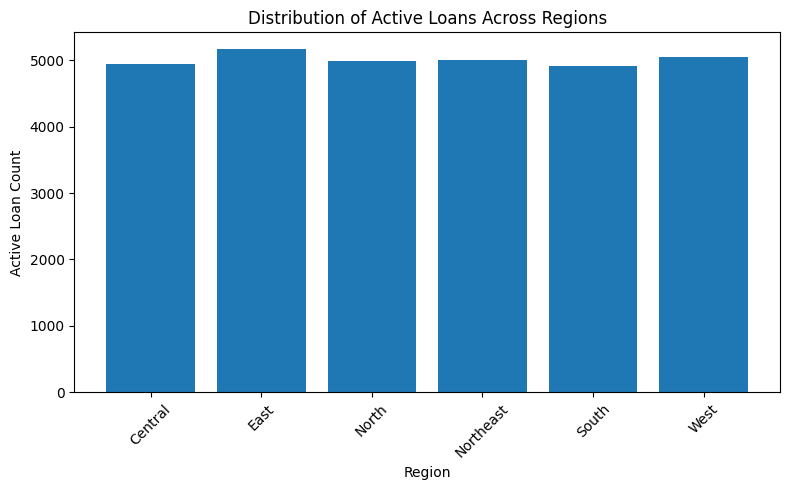

In [52]:
active_loans = loans[loans['Loan_Status'] == 'Active']
active_loans_region = active_loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
active_loan_distribution = active_loans_region.groupby('Region').agg(
    Active_Loan_Count=('Loan_ID', 'count')
).reset_index()
plt.figure(figsize=(8, 5))
plt.bar(active_loan_distribution['Region'], active_loan_distribution['Active_Loan_Count'])
plt.title('Distribution of Active Loans Across Regions')
plt.xlabel('Region')
plt.ylabel('Active Loan Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

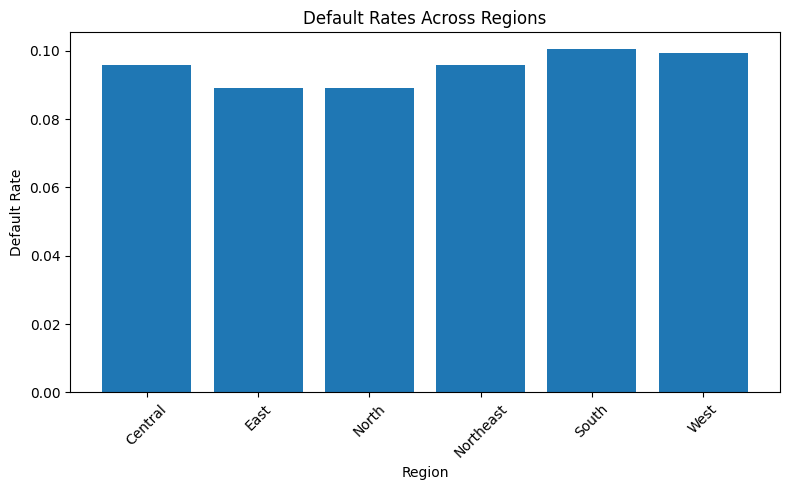

In [53]:
default_flag = defaults[['Loan_ID']].drop_duplicates()
default_flag['Is_Default'] = 1
loan_default = loans.merge(
    default_flag,
    on='Loan_ID',
    how='left'
)
loan_default['Is_Default'] = loan_default['Is_Default'].fillna(0)
loan_default_region = loan_default.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
region_default_rate = loan_default_region.groupby('Region').agg(
    Total_Loans=('Loan_ID', 'count'),
    Defaulted_Loans=('Is_Default', 'sum')
).reset_index()
region_default_rate['Default_Rate'] = (
    region_default_rate['Defaulted_Loans'] /
    region_default_rate['Total_Loans']
)
plt.figure(figsize=(8, 5))
plt.bar(region_default_rate['Region'], region_default_rate['Default_Rate'])
plt.title('Default Rates Across Regions')
plt.xlabel('Region')
plt.ylabel('Default Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

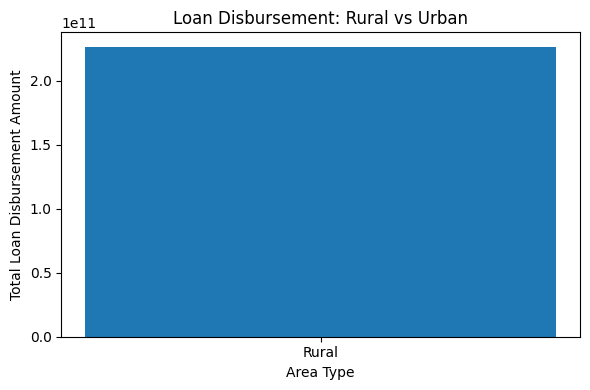

In [54]:
loan_region = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
loan_region['Area_Type'] = loan_region['Region'].apply(
    lambda x: 'Urban' if 'Urban' in str(x) else 'Rural'
)
area_disbursement = loan_region.groupby('Area_Type').agg(
    Total_Disbursement=('Loan_Amount', 'sum'),
    Loan_Count=('Loan_ID', 'count')
).reset_index()
plt.figure(figsize=(6, 4))
plt.bar(area_disbursement['Area_Type'], area_disbursement['Total_Disbursement'])
plt.title('Loan Disbursement: Rural vs Urban')
plt.xlabel('Area Type')
plt.ylabel('Total Loan Disbursement Amount')
plt.tight_layout()
plt.show()

#Task 14
Default Trends

In [55]:
defaults['Default_Month'] = defaults['Default_Date'].dt.to_period('M')
default_trend = defaults.groupby('Default_Month').agg(
    Default_Count=('Default_ID', 'count')
).reset_index()
default_trend

,Default_Month,Default_Count
0,2021-01,164
1,2021-02,171
2,2021-03,189
3,2021-04,196
4,2021-05,195
5,2021-06,181
6,2021-07,177
7,2021-08,192
8,2021-09,179
9,2021-10,171


In [56]:
default_purpose = defaults.merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)
avg_default_by_purpose = default_purpose.groupby('Loan_Purpose').agg(
    Avg_Default_Amount=('Default_Amount', 'mean'),
    Total_Default_Amount=('Default_Amount', 'sum'),
    Default_Count=('Default_ID', 'count')
).reset_index()
avg_default_by_purpose

,Loan_Purpose,Avg_Default_Amount,Total_Default_Amount,Default_Count
0,Business,53261.031433,72861091,1368
1,Education,53797.758769,75155469,1397
2,Home Renovation,53038.080028,74889769,1412
3,Personal,52389.399011,74183389,1416
4,Vehicle,52671.599578,74846343,1421


In [57]:
# Create income categories
customers['Income_Category'] = pd.cut(
    customers['Annual_Income'],
    bins=[0, 300000, 700000, float('inf')],
    labels=['Low Income', 'Middle Income', 'High Income']
)

# Create default flag at loan level
default_flag = defaults[['Loan_ID']].drop_duplicates()
default_flag['Is_Default'] = 1
loan_income = loans.merge(
    customers[['Customer_ID', 'Income_Category']],
    on='Customer_ID',
    how='left'
)
loan_income = loan_income.merge(
    default_flag,
    on='Loan_ID',
    how='left'
)
loan_income['Is_Default'] = loan_income['Is_Default'].fillna(0)
income_default_rate = loan_income.groupby('Income_Category').agg(
    Total_Loans=('Loan_ID', 'count'),
    Defaulted_Loans=('Is_Default', 'sum')
).reset_index()
income_default_rate['Default_Rate'] = (
    income_default_rate['Defaulted_Loans'] /
    income_default_rate['Total_Loans']
)
income_default_rate

/tmp/ipython-input-1085790951.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_default_rate = loan_income.groupby('Income_Category').agg(


,Income_Category,Total_Loans,Defaulted_Loans,Default_Rate
0,Low Income,5091,471.0,0.092516
1,Middle Income,19944,1898.0,0.095166
2,High Income,64965,6170.0,0.094974


#Task 15
Branch Efficiency

In [63]:
app_loan = applications.merge(
    loans[['Loan_ID', 'Disbursal_Date']],
    on='Loan_ID',
    how='left'
)
app_loan['Disbursement_Time_Days'] = (
    app_loan['Disbursal_Date'] - app_loan['Application_Date']
).dt.days
app_loan_region = app_loan.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
region_disbursement_time = app_loan_region.groupby('Region').agg(
    Avg_Disbursement_Time_Days=('Disbursement_Time_Days', 'mean'),
    Loan_Count=('Loan_ID', 'count')
).reset_index()
branch_disbursement_time = branches.merge(
    region_disbursement_time,
    on='Region',
    how='left'
)
branch_disbursement_time[
    ['Branch_ID', 'Branch_Name', 'Region', 'Avg_Disbursement_Time_Days', 'Loan_Count']
]

,Branch_ID,Branch_Name,Region,Avg_Disbursement_Time_Days,Loan_Count
0,B001,"Dhar, Kant and Madan",West,174.216119,11688
1,B002,Shan Group,East,169.508699,11840
2,B003,Sachdev-Banerjee,Central,165.453588,11484
3,B004,Kapadia-Brar,East,169.508699,11840
4,B005,"Mangal, Kaur and Borde",South,169.964289,11649
5,B006,Doshi Group,North,181.782092,11693
6,B007,"Lad, Wali and Ramesh",North,181.782092,11693
7,B008,Gala-Gara,Central,165.453588,11484
8,B009,Vasa Group,North,181.782092,11693
9,B010,Arya Ltd,West,174.216119,11688


In [62]:
rejected_apps = applications[applications['Approval_Status'] == 'Rejected']
rejected_by_region = rejected_apps.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
).groupby('Region').agg(
    Rejected_Application_Count=('Application_ID', 'count')
).reset_index()
branch_rejections = branches.merge(
    rejected_by_region,
    on='Region',
    how='left'
)
branch_rejections[['Branch_ID', 'Branch_Name', 'Region', 'Rejected_Application_Count']] \
    .sort_values(by='Rejected_Application_Count', ascending=False)

,Branch_ID,Branch_Name,Region,Rejected_Application_Count
0,B001,"Dhar, Kant and Madan",West,2184
9,B010,Arya Ltd,West,2184
11,B012,Kaul Inc,West,2184
41,B042,Kar-Jaggi,West,2184
26,B027,Kapadia-Ramakrishnan,West,2184
19,B020,Contractor-Sodhi,West,2184
14,B015,Apte Group,North,2112
16,B017,Doshi LLC,North,2112
6,B007,"Lad, Wali and Ramesh",North,2112
5,B006,Doshi Group,North,2112


#Task 16
Time-Series Analysis


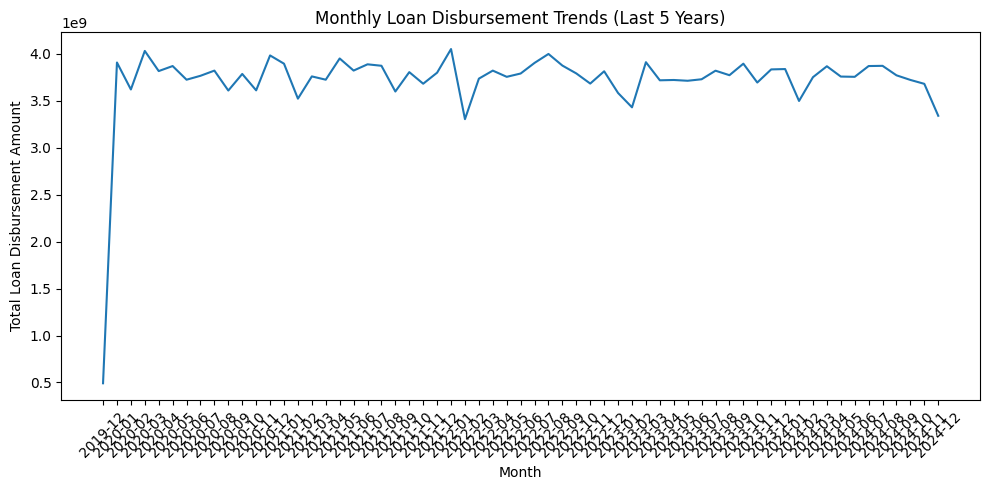

In [64]:
import matplotlib.pyplot as plt
import pandas as pd
loans['Disbursal_Date'] = pd.to_datetime(loans['Disbursal_Date'])
max_date = loans['Disbursal_Date'].max()
five_years_ago = max_date - pd.DateOffset(years=5)
loans_5y = loans[loans['Disbursal_Date'] >= five_years_ago]
loans_5y['Disbursal_Month'] = loans_5y['Disbursal_Date'].dt.to_period('M')
monthly_disbursement = loans_5y.groupby('Disbursal_Month').agg(
    Total_Loan_Amount=('Loan_Amount', 'sum')
).reset_index()
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_disbursement['Disbursal_Month'].astype(str),
    monthly_disbursement['Total_Loan_Amount']
)
plt.title('Monthly Loan Disbursement Trends (Last 5 Years)')
plt.xlabel('Month')
plt.ylabel('Total Loan Disbursement Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [66]:
applications['App_Month'] = applications['Application_Date'].dt.month
loans['Disb_Month'] = loans['Disbursal_Date'].dt.month
seasonal_applications = applications.groupby('App_Month').agg(
    Application_Count=('Application_ID', 'count')
).reset_index()
seasonal_disbursements = loans.groupby('Disb_Month').agg(
    Total_Disbursement=('Loan_Amount', 'sum'),
    Loan_Count=('Loan_ID', 'count')
).reset_index()
seasonal_applications, seasonal_disbursements

(    App_Month  Application_Count
 0           1               7124
 1           2               6397
 2           3               6863
 3           4               6781
 4           5               6998
 5           6               6808
 6           7               7215
 7           8               6952
 8           9               6762
 9          10               6952
 10         11               6749
 11         12               6999,
     Disb_Month  Total_Disbursement  Loan_Count
 0            1         19277466570        7677
 1            2         17378372459        6949
 2            3         19191521797        7611
 3            4         18951193634        7481
 4            5         19058006928        7590
 5            6         18807860613        7356
 6            7         19160061110        7603
 7            8         19388634744        7722
 8            9         18629133713        7424
 9           10         19002172028        7637
 10          11         18353

In [67]:
defaults['Default_Month'] = defaults['Default_Date'].dt.to_period('M')
defaults_region = defaults.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
loans['Disbursal_Month'] = loans['Disbursal_Date'].dt.to_period('M')
loans_region = loans.merge(
    customers[['Customer_ID', 'Region']],
    on='Customer_ID',
    how='left'
)
region_month_loans = loans_region.groupby(
    ['Region', 'Disbursal_Month']
).agg(
    Total_Loans=('Loan_ID', 'count')
).reset_index()
region_month_defaults = defaults_region.groupby(
    ['Region', 'Default_Month']
).agg(
    Defaulted_Loans=('Default_ID', 'count')
).reset_index()
region_month_defaults.rename(
    columns={'Default_Month': 'Disbursal_Month'},
    inplace=True
)
region_month_default_rate = region_month_loans.merge(
    region_month_defaults,
    on=['Region', 'Disbursal_Month'],
    how='left'
)
region_month_default_rate['Defaulted_Loans'] = region_month_default_rate['Defaulted_Loans'].fillna(0)

region_month_default_rate['Default_Rate'] = (
    region_month_default_rate['Defaulted_Loans'] /
    region_month_default_rate['Total_Loans']
)
region_month_default_rate

,Region,Disbursal_Month,Total_Loans,Defaulted_Loans,Default_Rate
0,Central,2019-12,31,0.0,0.000000
1,Central,2020-01,269,0.0,0.000000
2,Central,2020-02,241,0.0,0.000000
3,Central,2020-03,243,0.0,0.000000
4,Central,2020-04,248,0.0,0.000000
...,...,...,...,...,...
361,West,2024-08,235,27.0,0.114894
362,West,2024-09,251,20.0,0.079681
363,West,2024-10,261,19.0,0.072797
364,West,2024-11,257,28.0,0.108949


#Task 17
Customer Behavior Analysis


In [70]:
customer_repayment = transactions.groupby('Customer_ID').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Overdue_Transactions=('Overdue_Fee', lambda x: (x > 0).sum())
).reset_index()
customer_repayment['Overdue_Ratio'] = (
    customer_repayment['Overdue_Transactions'] /
    customer_repayment['Total_Transactions']
)
customer_repayment['Repayment_Category'] = customer_repayment['Overdue_Ratio'].apply(
    lambda x: 'Always On Time' if x == 0
    else 'Occasional Defaulter' if x <= 0.3
    else 'Frequent Defaulter'
)
customer_repayment[['Customer_ID', 'Total_Transactions', 'Overdue_Transactions', 'Repayment_Category']]

,Customer_ID,Total_Transactions,Overdue_Transactions,Repayment_Category
0,C000003,9,4,Frequent Defaulter
1,C000004,13,7,Frequent Defaulter
2,C000005,2,0,Always On Time
3,C000007,8,4,Frequent Defaulter
4,C000008,3,3,Frequent Defaulter
...,...,...,...,...
50585,C069994,4,2,Frequent Defaulter
50586,C069997,10,5,Frequent Defaulter
50587,C069998,5,2,Frequent Defaulter
50588,C069999,7,4,Frequent Defaulter


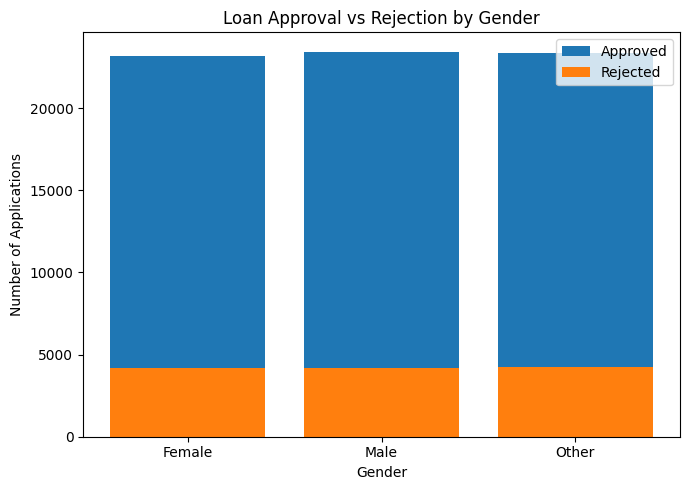

/tmp/ipython-input-3896694834.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ].groupby(


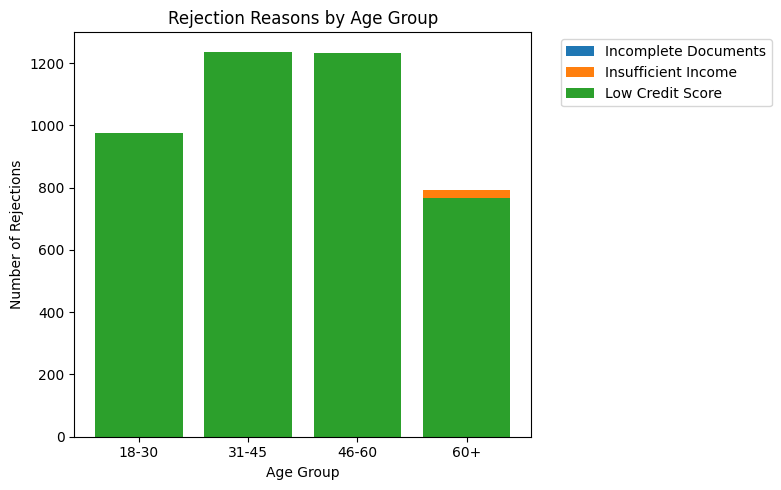

In [73]:
app_demo = applications.merge(
    customers[['Customer_ID', 'Gender', 'Age']],
    on='Customer_ID',
    how='left'
)
app_demo['Age_Group'] = pd.cut(
    app_demo['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)
gender_status = app_demo.groupby(
    ['Gender', 'Approval_Status']
).size().reset_index(name='Count')
plt.figure(figsize=(7,5))
for status in gender_status['Approval_Status'].unique():
    subset = gender_status[gender_status['Approval_Status'] == status]
    plt.bar(subset['Gender'], subset['Count'], label=status)
plt.title('Loan Approval vs Rejection by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Applications')
plt.legend()
plt.tight_layout()
plt.show()
rejection_age = app_demo[
    app_demo['Approval_Status'] == 'Rejected'
].groupby(
    ['Age_Group', 'Rejection_Reason']
).size().reset_index(name='Count')
plt.figure(figsize=(8,5))
for reason in rejection_age['Rejection_Reason'].unique():
    subset = rejection_age[rejection_age['Rejection_Reason'] == reason]
    plt.bar(subset['Age_Group'].astype(str), subset['Count'], label=reason)
plt.title('Rejection Reasons by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Rejections')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [78]:
high_value_customers = customers[
    (customers['Annual_Income'] >= 700000) &
    (customers['Credit_Score'] >= 750)
][['Customer_ID']]
repayment_behavior = transactions.groupby('Customer_ID').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Overdue_Transactions=('Overdue_Fee', lambda x: (x > 0).sum())
).reset_index()
consistent_repayment = repayment_behavior[
    repayment_behavior['Overdue_Transactions'] == 0
][['Customer_ID', 'Total_Transactions']]
high_value_consistent_customers = high_value_customers.merge(
    consistent_repayment,
    on='Customer_ID',
    how='inner'
)
high_value_consistent_customers = high_value_consistent_customers.sort_values(
    by='Total_Transactions',
    ascending=False
)
high_value_consistent_customers

,Customer_ID,Total_Transactions
77,C029725,10
7,C003368,9
157,C061066,8
126,C048616,8
152,C059576,8
...,...,...
133,C052350,1
163,C063254,1
156,C060997,1
173,C065619,1


#Task 18
Risk Assessment

/tmp/ipython-input-1079992283.py:17: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  risk_matrix = loan_risk.pivot_table(


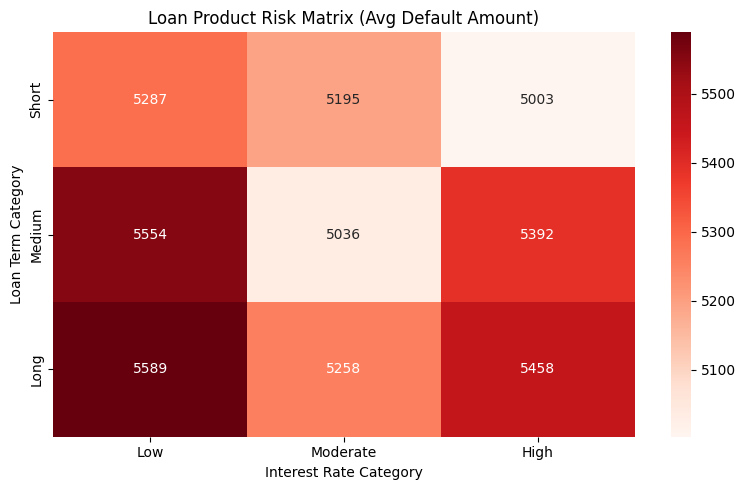

In [80]:
loan_risk = loans.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)
loan_risk['Default_Amount'] = loan_risk['Default_Amount'].fillna(0)
loan_risk['Loan_Term_Bucket'] = pd.cut(
    loan_risk['Loan_Term'],
    bins=[0, 12, 36, 60, float('inf')],
    labels=['Short', 'Medium', 'Long', 'Very Long']
)
loan_risk['Interest_Rate_Bucket'] = pd.cut(
    loan_risk['Interest_Rate'],
    bins=[0, 8, 12, 16, float('inf')],
    labels=['Low', 'Moderate', 'High', 'Very High']
)
risk_matrix = loan_risk.pivot_table(
    values='Default_Amount',
    index='Loan_Term_Bucket',
    columns='Interest_Rate_Bucket',
    aggfunc='mean'
)
plt.figure(figsize=(8, 5))
sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".0f",
    cmap='Reds'
)
plt.title('Loan Product Risk Matrix (Avg Default Amount)')
plt.xlabel('Interest Rate Category')
plt.ylabel('Loan Term Category')
plt.tight_layout()
plt.show()

In [82]:
loan_type_risk = loans.merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)
loan_type_risk = loan_type_risk.merge(
    defaults[['Loan_ID', 'Default_Amount']],
    on='Loan_ID',
    how='left'
)
loan_type_risk['Default_Amount'] = loan_type_risk['Default_Amount'].fillna(0)
loan_type_risk_rank = loan_type_risk.groupby('Loan_Purpose').agg(
    Avg_Default_Amount=('Default_Amount', 'mean'),
    Total_Default_Amount=('Default_Amount', 'sum'),
    Loan_Count=('Loan_ID', 'count'),
    Defaulted_Loans=('Default_Amount', lambda x: (x > 0).sum())
).reset_index()
loan_type_risk_rank['Default_Rate'] = (
    loan_type_risk_rank['Defaulted_Loans'] /
    loan_type_risk_rank['Loan_Count']
)
loan_type_risk_rank = loan_type_risk_rank.sort_values(
    by='Avg_Default_Amount',
    ascending=False
)
loan_type_risk_rank

,Loan_Purpose,Avg_Default_Amount,Total_Default_Amount,Loan_Count,Defaulted_Loans,Default_Rate
1,Education,5353.716270,75155469.0,14038,1397,0.099516
2,Home Renovation,5314.346367,74889769.0,14092,1412,0.100199
3,Personal,5297.299986,74183389.0,14004,1416,0.101114
4,Vehicle,5285.012216,74846343.0,14162,1421,0.100339
0,Business,5180.680532,72861091.0,14064,1368,0.097270


In [83]:
high_risk_customers = defaults[['Customer_ID', 'Default_Amount']]
high_risk_demo = high_risk_customers.merge(
    customers[['Customer_ID', 'Credit_Score', 'Annual_Income']],
    on='Customer_ID',
    how='left'
)
high_risk_demo['Credit_Segment'] = pd.cut(
    high_risk_demo['Credit_Score'],
    bins=[0, 600, 700, 800, 900],
    labels=['Poor', 'Fair', 'Good', 'Excellent']
)
high_risk_demo['Income_Segment'] = pd.cut(
    high_risk_demo['Annual_Income'],
    bins=[0, 300000, 700000, float('inf')],
    labels=['Low Income', 'Middle Income', 'High Income']
)
high_risk_segment_analysis = high_risk_demo.groupby(
    ['Credit_Segment', 'Income_Segment']
).agg(
    High_Risk_Customer_Count=('Customer_ID', 'count'),
    Total_Default_Amount=('Default_Amount', 'sum'),
    Avg_Default_Amount=('Default_Amount', 'mean')
).reset_index()
high_risk_segment_analysis

/tmp/ipython-input-3641289874.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  high_risk_segment_analysis = high_risk_demo.groupby(


,Credit_Segment,Income_Segment,High_Risk_Customer_Count,Total_Default_Amount,Avg_Default_Amount
0,Poor,Low Income,219,11277103,51493.621005
1,Poor,Middle Income,815,43269381,53091.265031
2,Poor,High Income,2823,149884119,53093.913921
3,Fair,Low Income,67,3624075,54090.671642
4,Fair,Middle Income,292,15288102,52356.513699
5,Fair,High Income,912,48372499,53040.020833
6,Good,Low Income,71,3670995,51704.154930
7,Good,Middle Income,277,14474978,52256.238267
8,Good,High Income,912,48715237,53415.830044
9,Excellent,Low Income,32,1718603,53706.343750


#Task 19
 Time to Default Analysis

In [86]:
default_timing = defaults.merge(
    loans[['Loan_ID', 'Disbursal_Date']],
    on='Loan_ID',
    how='left'
)
default_timing['Days_To_Default'] = (
    default_timing['Default_Date'] - default_timing['Disbursal_Date']
).dt.days
default_timing = default_timing[
    default_timing['Days_To_Default'].notna() &
    (default_timing['Days_To_Default'] >= 0)
]
avg_time_to_default = default_timing['Days_To_Default'].mean()
avg_time_to_default

np.float64(630.6970077047124)

In [89]:
default_purpose_timing = defaults.merge(
    loans[['Loan_ID', 'Disbursal_Date']],
    on='Loan_ID',
    how='left'
).merge(
    applications[['Loan_ID', 'Loan_Purpose']],
    on='Loan_ID',
    how='left'
)
default_purpose_timing['Days_To_Default'] = (
    default_purpose_timing['Default_Date'] -
    default_purpose_timing['Disbursal_Date']
).dt.days
default_purpose_timing = default_purpose_timing[
    default_purpose_timing['Days_To_Default'].notna() &
    (default_purpose_timing['Days_To_Default'] >= 0)
]
loan_purpose_shortest_default = (
    default_purpose_timing
    .groupby('Loan_Purpose')['Days_To_Default']
    .mean()
    .reset_index(name='Avg_Days_To_Default')
    .sort_values(by='Avg_Days_To_Default', ascending=True)
)
loan_purpose_shortest_default

,Loan_Purpose,Avg_Days_To_Default
3,Personal,612.226190
1,Education,617.936768
0,Business,626.122786
2,Home Renovation,631.974299
4,Vehicle,659.708145


In [96]:
default_demo = defaults.merge(
    loans[['Loan_ID', 'Customer_ID', 'Disbursal_Date']],
    on='Loan_ID',
    how='left'
)
default_demo.rename(columns={'Customer_ID_x': 'Customer_ID'}, inplace=True)
default_demo = default_demo.merge(
    customers[['Customer_ID', 'Gender', 'Age']],
    on='Customer_ID',
    how='left'
)
default_demo['Days_To_Default'] = (
    default_demo['Default_Date'] -
    default_demo['Disbursal_Date']
).dt.days
default_demo = default_demo[
    default_demo['Days_To_Default'].notna() &
    (default_demo['Days_To_Default'] >= 0)
]
default_demo['Age_Group'] = pd.cut(
    default_demo['Age'],
    bins=[18, 30, 45, 60, 100],
    labels=['18-30', '31-45', '46-60', '60+']
)
time_to_default_demographics = default_demo.groupby(
    ['Gender', 'Age_Group']
).agg(
    Avg_Days_To_Default=('Days_To_Default', 'mean'),
    Default_Count=('Loan_ID', 'count')
).reset_index()
time_to_default_demographics

/tmp/ipython-input-199085005.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  time_to_default_demographics = default_demo.groupby(


,Gender,Age_Group,Avg_Days_To_Default,Default_Count
0,Female,18-30,593.265130,347
1,Female,31-45,646.667500,400
2,Female,46-60,630.121839,435
3,Female,60+,701.240506,237
4,Male,18-30,624.283582,335
5,Male,31-45,601.191542,402
6,Male,46-60,628.706024,415
7,Male,60+,635.527675,271
8,Other,18-30,613.558824,340
9,Other,31-45,662.511848,422


#Task 20
Transaction Pattern Analysis


In [99]:
repayment_pattern = transactions.groupby('Customer_ID').agg(
    Total_Transactions=('Transaction_ID', 'count'),
    Overdue_Transactions=('Overdue_Fee', lambda x: (x > 0).sum())
).reset_index()
irregular_repayment_customers = repayment_pattern[
    (repayment_pattern['Overdue_Transactions'] > 0) &
    (repayment_pattern['Overdue_Transactions'] < repayment_pattern['Total_Transactions'])
]
irregular_repayment_customers

,Customer_ID,Total_Transactions,Overdue_Transactions
0,C000003,9,4
1,C000004,13,7
3,C000007,8,4
5,C000011,16,7
6,C000012,7,5
...,...,...,...
50585,C069994,4,2
50586,C069997,10,5
50587,C069998,5,2
50588,C069999,7,4


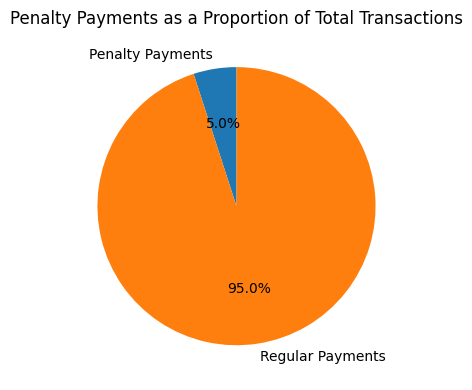

In [104]:
total_transaction_amount = transactions['Amount'].sum()
total_penalty_amount = transactions['Overdue_Fee'].sum()
labels = ['Penalty Payments', 'Regular Payments']
values = [total_penalty_amount, total_transaction_amount - total_penalty_amount]
plt.figure(figsize=(6, 4))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Penalty Payments as a Proportion of Total Transactions')
plt.tight_layout()
plt.show()

In [106]:
transactions['Overdue_Status'] = transactions['Overdue_Fee'].apply(
    lambda x: 'Overdue' if x > 0 else 'Non-Overdue'
)
transaction_amount_comparison = transactions.groupby('Overdue_Status').agg(
    Avg_Transaction_Amount=('Amount', 'mean'),
    Total_Transaction_Amount=('Amount', 'sum'),
    Transaction_Count=('Transaction_ID', 'count')
).reset_index()
transaction_amount_comparison

,Overdue_Status,Avg_Transaction_Amount,Total_Transaction_Amount,Transaction_Count
0,Non-Overdue,25508.590853,6314626157,247549
1,Overdue,25484.253028,6306103896,247451


#Collective Agenda
The goal of this analysis is to help Hero FinCorp reduce loan risk, improve branch performance, and increase profitability by using insights from customer and loan data.
# 1. Reducing Loan Defaults
we can reduce Loan defaults by identifying customers and regions that carry higher risk early in the loans. Customers with low credit scores, lower income levels, past defaults, or irregular repayment behavior should be closely monitored. These customers may benefit from stricter eligibility checks, smaller loan amounts, or shorter loan tenures.Early warning signals such as delayed payments or increasing overdue fees can help the business intervene before a loan turns into a full default.
# 2. Improving Branch Operations
Branch performance are different when it comes to loan processing time and recovery efficiency. Branches with longer processing delays can improve by streamlining workflows, using automation, and providing additional training to staff and Recovery analysis shows that timely follow-ups and legal actions improve recovery rates. Branches with high rejection rates should review their application screening process to ensure efficiency without rejecting good customers.
# 3. Increasing Profitability
we can improve the Profitability by focusing on the right customers and loan products. High-value customers who are repaying the amount on time are ideal candidates for better interest rates, higher loan limits, and loyalty benefits. Retaining these customers can significantly increase long-term revenue.we can scale up the Lower-risk loan products with faster approvals, while higher-risk loans should be scaled carefully to reflect the risk.
